# 03. Phân tích adapter LoRA

Notebook này đọc lại các checkpoint LoRA đã huấn luyện và kiểm tra phần cập nhật trọng số low-rank. Mục tiêu không phải train lại, mà là nhìn vào adapter đã học để xác nhận rằng thí nghiệm thật sự tạo ra các cập nhật dạng low-rank.

Notebook tạo hai loại phân tích:

- Singular values của ma trận cập nhật `Delta W = BA`.
- Frobenius norm trung bình của các cập nhật LoRA.

Lưu ý: mô tả ban đầu có nhắc LoRTA, nhưng bản hiện thực báo cáo LoRA rank sweep. Vì vậy notebook này đóng vai trò phân tích LoRA adapter thay vì claim đã hiện thực LoRTA đầy đủ.

## Bước 1. Đặt đúng thư mục làm việc

Cell này đưa notebook về thư mục `deep-learning` để đọc được config, checkpoint và ghi hình vào `results/plots/`.

In [1]:
from pathlib import Path
import os

root = Path.cwd()
if root.name == "notebooks":
    root = root.parent
os.chdir(root)
print(f"Thư mục làm việc: {Path.cwd()}")

Thư mục làm việc: d:\HK6\Machine learning\Lab_3\csc14005-introduction-to-machine-learning\lab-3\deep-learning


## Bước 2. Đọc checkpoint và trích thông tin adapter

Cell này làm các việc sau:

1. Đọc config LoRA rank 2, 4 và 8.
2. Tìm checkpoint tốt nhất tại `results/runs/<run_name>/best_model.pt`.
3. Build lại model đúng cấu hình.
4. Load checkpoint.
5. Duyệt qua các layer LoRA bằng `iter_lora_layers`.
6. Tính `delta_weight()` cho từng layer.
7. Lưu singular values và Frobenius norm vào dataframe.

Nếu checkpoint chưa tồn tại, notebook sẽ bỏ qua cấu hình đó và in thông báo. Vì vậy cần chạy `02_lora_sweep.ipynb` hoặc script train trước notebook này.

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch

from src.config import load_config
from src.lora import iter_lora_layers
from src.model import build_model_and_tokenizer

configs = ["configs/lora_r2.yaml", "configs/lora_r4.yaml", "configs/lora_r8.yaml"]
singular_rows = []
norm_rows = []

for config_path in configs:
    config = load_config(config_path)
    run_name = config["experiment"]["name"]
    checkpoint = Path(config.get("output_dir", "results/runs")) / run_name / "best_model.pt"
    if not checkpoint.exists():
        print(f"Bỏ qua {run_name}: chưa có checkpoint {checkpoint}")
        continue

    model, _, _ = build_model_and_tokenizer(config)
    model.load_state_dict(torch.load(checkpoint, map_location="cpu"))
    rank = config["lora"]["rank"]

    for layer_name, layer in iter_lora_layers(model):
        delta = layer.delta_weight().detach().cpu()
        norm_rows.append({"run_name": run_name, "rank": rank, "layer": layer_name, "delta_norm": float(delta.norm())})
        for index, value in enumerate(torch.linalg.svdvals(delta)[:16]):
            singular_rows.append({"run_name": run_name, "rank": rank, "layer": layer_name, "sv_index": index + 1, "singular_value": float(value)})

sv_df = pd.DataFrame(singular_rows)
norm_df = pd.DataFrame(norm_rows)
sv_df.head()

d:\HK6\Machine learning\Lab_3\csc14005-introduction-to-machine-learning\lab-3\deep-learning\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at prajjwal1/bert-tiny and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at prajjwal1/bert-tiny and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of BertForSequenceClassification were not initialized from the model checkpo

,run_name,rank,layer,sv_index,singular_value
0,lora_r2,2,bert.encoder.layer.0.attention.self.query,1,2.258246e+00
1,lora_r2,2,bert.encoder.layer.0.attention.self.query,2,4.944310e-02
2,lora_r2,2,bert.encoder.layer.0.attention.self.query,3,5.106255e-07
3,lora_r2,2,bert.encoder.layer.0.attention.self.query,4,3.549153e-07
4,lora_r2,2,bert.encoder.layer.0.attention.self.query,5,3.303244e-07


## Bước 3. Vẽ biểu đồ diagnostic

Cell này sinh hai hình:

- `lora_singular_values.png`: cho thấy phổ singular value của cập nhật LoRA. Với low-rank update, chỉ một số ít singular values đáng kể.
- `lora_delta_norms.png`: so sánh độ lớn trung bình của cập nhật LoRA giữa các rank.

Hai hình này không bắt buộc trong bảng kết quả chính, nhưng hữu ích khi giải thích vì sao LoRA liên quan trực tiếp đến low-rank factorization trong tutorial.

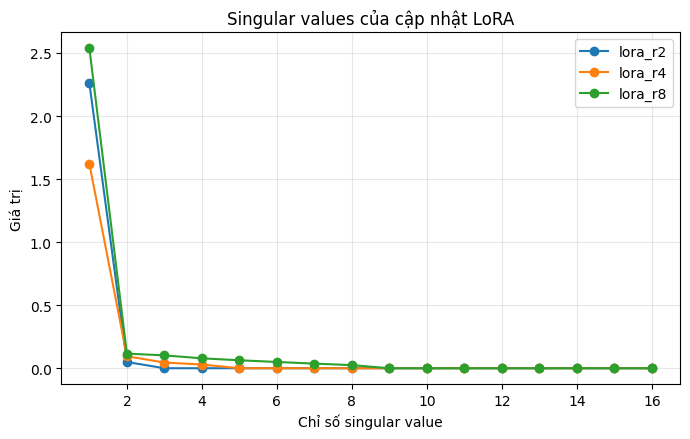

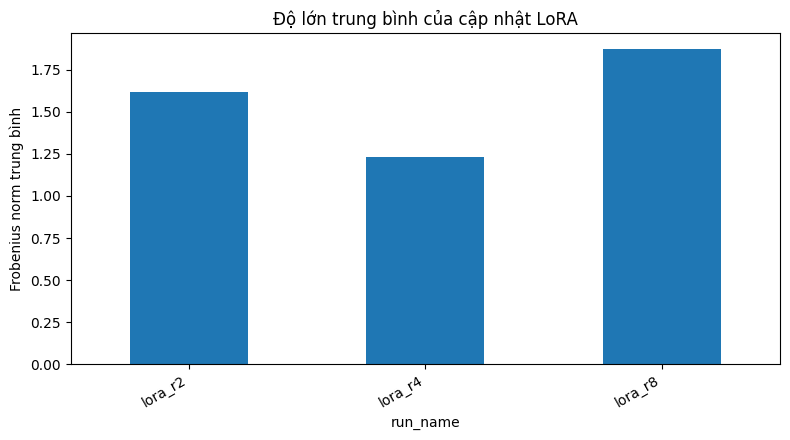

In [3]:
out_dir = Path("results/plots")
out_dir.mkdir(parents=True, exist_ok=True)

if not sv_df.empty:
    first_layers = sv_df.groupby("run_name").head(16)
    plt.figure(figsize=(7, 4.5))
    for run_name, group in first_layers.groupby("run_name"):
        plt.plot(group["sv_index"], group["singular_value"], marker="o", label=run_name)
    plt.xlabel("Chỉ số singular value")
    plt.ylabel("Giá trị")
    plt.title("Singular values của cập nhật LoRA")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_dir / "lora_singular_values.png", dpi=200)
    plt.show()

if not norm_df.empty:
    plt.figure(figsize=(8, 4.5))
    norm_df.groupby("run_name")["delta_norm"].mean().plot(kind="bar")
    plt.ylabel("Frobenius norm trung bình")
    plt.title("Độ lớn trung bình của cập nhật LoRA")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.savefig(out_dir / "lora_delta_norms.png", dpi=200)
    plt.show()

## Diễn giải

Nếu biểu đồ singular values giảm nhanh hoặc chỉ có một số ít giá trị khác 0 đáng kể, điều đó phù hợp với bản chất low-rank của LoRA. Frobenius norm cho biết adapter đã thay đổi trọng số mạnh đến mức nào ở từng rank. Các phân tích này hỗ trợ phần lý thuyết trong báo cáo: LoRA là matrix low-rank adaptation, còn các hướng như LoRTA mở rộng ý tưởng đó sang tensor adaptation.